In [1]:
pip install opencv-python tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_DIR = "vault"
OUTPUT_DIR = "dataset/pix2pix_training"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_SIZE = (256,256)  # (width, height) for OpenCV

def safe_read(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)  # forces 3-channel BGR
    return img

def create_pairs(limit_groups=50):
    print(f"Starting pairing for {limit_groups} groups...")

    for group_id in tqdm(range(1, limit_groups + 1), desc="Processing Groups"):
        folder_name = f"{group_id:04d}"
        folder_path = os.path.join(BASE_DIR, folder_name)

        if not os.path.exists(folder_path):
            continue

        for i in range(1, 61, 2):
            clean_path = os.path.join(folder_path, f"c-{group_id:03d}-{i}.jpg")
            noisy_path = os.path.join(folder_path, f"c-{group_id:03d}-{i+1}.jpg")

            if not (os.path.exists(clean_path) and os.path.exists(noisy_path)):
                continue

            img_clean = safe_read(clean_path)
            img_noisy = safe_read(noisy_path)

            if img_clean is None or img_noisy is None:
                print(f"\n[!] Error loading images in group {group_id}, pair {i}")
                continue

            # Resize both to fixed size for Pix2Pix consistency
            img_clean_r = cv2.resize(img_clean, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            img_noisy_r = cv2.resize(img_noisy, TARGET_SIZE, interpolation=cv2.INTER_AREA)

            combined = np.hstack((img_noisy_r, img_clean_r))

            pair_name = f"g{group_id:04d}_p{i:02d}.jpg"
            cv2.imwrite(os.path.join(OUTPUT_DIR, pair_name), combined)

    print(f"\nDone! Files saved to: {OUTPUT_DIR}")

create_pairs(50)

Starting pairing for 50 groups...


Processing Groups: 100%|██████████| 50/50 [00:10<00:00,  4.89it/s]


Done! Files saved to: dataset/pix2pix_training


In [5]:
import os
files = os.listdir("dataset/pix2pix_training")
print(f"Total images created: {len(files)}")

Total images created: 1201


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
import numpy as np

# OPTIMIZATION FOR H100
torch.set_float32_matmul_precision('high')

# --- GENERATOR (U-Net) ---
class UnetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, submodule=None, innermost=False, outermost=False, dropout=False):
        super().__init__()
        self.outermost = outermost
        if outermost:
            down = nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)
            up = nn.Sequential(nn.ReLU(True), nn.ConvTranspose2d(out_ch*2, in_ch, 4, 2, 1), nn.Tanh())
            self.model = nn.Sequential(down, submodule, up)
        elif innermost:
            down = nn.Sequential(nn.LeakyReLU(0.2, True), nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
            up = nn.Sequential(nn.ReLU(True), nn.ConvTranspose2d(out_ch, in_ch, 4, 2, 1, bias=False), nn.BatchNorm2d(in_ch))
            self.model = nn.Sequential(down, up)
        else:
            down = nn.Sequential(nn.LeakyReLU(0.2, True), nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False), nn.BatchNorm2d(out_ch))
            up = nn.Sequential(nn.ReLU(True), nn.ConvTranspose2d(out_ch*2, in_ch, 4, 2, 1, bias=False), nn.BatchNorm2d(in_ch))
            if dropout: up.add_module("dropout", nn.Dropout(0.5))
            self.model = nn.Sequential(down, submodule, up)

    def forward(self, x):
        if self.outermost: return self.model(x)
        else: return torch.cat([x, self.model(x)], 1)

class UnetGenerator(nn.Module):
    def __init__(self, in_nc=3, out_nc=3, num_downs=8, ngf=64):
        super().__init__()
        unet_block = UnetBlock(ngf * 8, ngf * 8, innermost=True)
        for _ in range(num_downs - 5):
            unet_block = UnetBlock(ngf * 8, ngf * 8, submodule=unet_block, dropout=True)
        unet_block = UnetBlock(ngf * 4, ngf * 8, submodule=unet_block)
        unet_block = UnetBlock(ngf * 2, ngf * 4, submodule=unet_block)
        unet_block = UnetBlock(ngf, ngf * 2, submodule=unet_block)
        self.model = UnetBlock(out_nc, ngf, submodule=unet_block, outermost=True)

    def forward(self, x): return self.model(x)

# --- DISCRIMINATOR (PatchGAN) ---
class Discriminator(nn.Module):
    def __init__(self, in_nc=6): # 6 because it takes (input + target)
        super().__init__()
        def cb(in_c, out_c, s=2): return nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, s, 1, bias=False), nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2, True))
        self.model = nn.Sequential(cb(in_nc, 64), cb(64, 128), cb(128, 256), cb(256, 512, s=1),
                                   nn.Conv2d(512, 1, 4, 1, 1), nn.Sigmoid())
    def forward(self, x): return self.model(x)

In [12]:
class Pix2PixDataset(Dataset):
    def __init__(self, root):
        self.root = root
        self.files = sorted([f for f in os.listdir(root) if f.endswith('.jpg')])
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
        ])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.files[idx])).convert('RGB')
        w, h = img.size
        # Left = Stamped (A), Right = Clean (B)
        img_a = self.transform(img.crop((0, 0, w//2, h)))
        img_b = self.transform(img.crop((w//2, 0, w, h)))
        return img_a, img_b

In [13]:
# Configuration
device = torch.device("cuda")
BATCH_SIZE = 16 
LR = 0.0002
LAMBDA_L1 = 100
EPOCHS = 100

# Initialize Models
netG = UnetGenerator().to(device)
netD = Discriminator().to(device)

# Loss & Optimizers
criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()
optG = optim.Adam(netG.parameters(), lr=LR, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=LR, betas=(0.5, 0.999))

# Data
train_data = DataLoader(Pix2PixDataset('dataset/signature_recovery_final/train'), batch_size=BATCH_SIZE, shuffle=True)

# Training Loop
for epoch in range(EPOCHS):
    for i, (real_a, real_b) in enumerate(train_data):
        real_a, real_b = real_a.to(device), real_b.to(device)

        # --- Train Discriminator ---
        optD.zero_grad()
        fake_b = netG(real_a)
        
        # Real loss
        pred_real = netD(torch.cat([real_a, real_b], 1))
        loss_d_real = criterion_GAN(pred_real, torch.ones_like(pred_real))
        
        # Fake loss
        pred_fake = netD(torch.cat([real_a, fake_b.detach()], 1))
        loss_d_fake = criterion_GAN(pred_fake, torch.zeros_like(pred_fake))
        
        loss_d = (loss_d_real + loss_d_fake) * 0.5
        loss_d.backward()
        optD.step()

        # --- Train Generator ---
        optG.zero_grad()
        pred_fake = netD(torch.cat([real_a, fake_b], 1))
        loss_g_gan = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
        loss_g_l1 = criterion_L1(fake_b, real_b) * LAMBDA_L1
        
        loss_g = loss_g_gan + loss_g_l1
        loss_g.backward()
        optG.step()

        if i % 10 == 0:
            print(f"Epoch [{epoch}/{EPOCHS}] Batch {i} | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

# Save the final high-precision weights
torch.save(netG.state_dict(), "signature_recovery_h100.pth")

Epoch [0/100] Batch 0 | Loss D: 0.7223 | Loss G: 80.9740
Epoch [0/100] Batch 10 | Loss D: 0.4324 | Loss G: 36.5197
Epoch [0/100] Batch 20 | Loss D: 0.1930 | Loss G: 23.6442
Epoch [0/100] Batch 30 | Loss D: 0.1051 | Loss G: 17.3127
Epoch [0/100] Batch 40 | Loss D: 0.3237 | Loss G: 12.2655
Epoch [0/100] Batch 50 | Loss D: 0.3097 | Loss G: 10.5800
Epoch [0/100] Batch 60 | Loss D: 0.3042 | Loss G: 8.9408
Epoch [1/100] Batch 0 | Loss D: 0.1980 | Loss G: 10.8953
Epoch [1/100] Batch 10 | Loss D: 0.3317 | Loss G: 7.7056
Epoch [1/100] Batch 20 | Loss D: 0.2159 | Loss G: 9.3573
Epoch [1/100] Batch 30 | Loss D: 0.2964 | Loss G: 5.6275
Epoch [1/100] Batch 40 | Loss D: 0.1903 | Loss G: 9.4638
Epoch [1/100] Batch 50 | Loss D: 0.2434 | Loss G: 6.8180
Epoch [1/100] Batch 60 | Loss D: 0.1280 | Loss G: 8.9229
Epoch [2/100] Batch 0 | Loss D: 0.8401 | Loss G: 8.9155
Epoch [2/100] Batch 10 | Loss D: 0.2985 | Loss G: 8.2631
Epoch [2/100] Batch 20 | Loss D: 0.2905 | Loss G: 9.4173
Epoch [2/100] Batch 30 | Lo

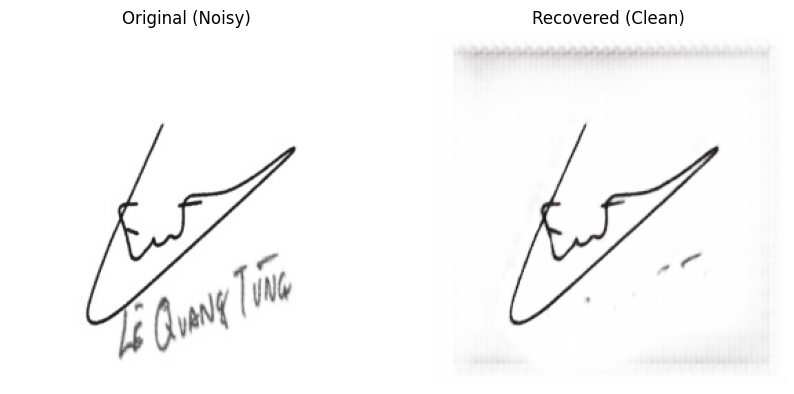

In [14]:
import torch
import matplotlib.pyplot as plt

# 1. Load the trained model
device = torch.device("cuda")
model = UnetGenerator().to(device)
model.load_state_dict(torch.load("signature_recovery_h100.pth"))
model.eval() # Set to evaluation mode

def test_signature(image_path):
    # Load and transform the image
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    # If using your combined val images, we need to crop the left side (Noisy)
    full_img = Image.open(image_path).convert('RGB')
    w, h = full_img.size
    noisy_img = full_img.crop((0, 0, w//2, h)) # Take the left half
    
    input_tensor = transform(noisy_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
    
    # De-normalize from [-1, 1] to [0, 1] for display
    output = output.cpu().squeeze(0).permute(1, 2, 0)
    output = (output + 1) / 2
    output = torch.clamp(output, 0, 1).numpy()
    
    # Display Results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original (Noisy)")
    plt.imshow(noisy_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Recovered (Clean)")
    plt.imshow(output)
    plt.axis('off')
    plt.show()

# 2. Test on a sample from your Validation set
val_path = 'dataset/signature_recovery_final/val'
sample_file = os.path.join(val_path, os.listdir(val_path)[0])
test_signature(sample_file)

In [15]:
def save_as_transparent_png(numpy_img, output_name):
    # Convert to grayscale to find ink
    gray = cv2.cvtColor((numpy_img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    
    # Use thresholding to separate ink from paper
    _, alpha = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    
    # Merge RGB channels with Alpha channel
    b, g, r = cv2.split((numpy_img * 255).astype(np.uint8))
    rgba = cv2.merge([b, g, r, alpha])
    
    cv2.imwrite(output_name, rgba)
    print(f"Transparent signature saved as {output_name}")



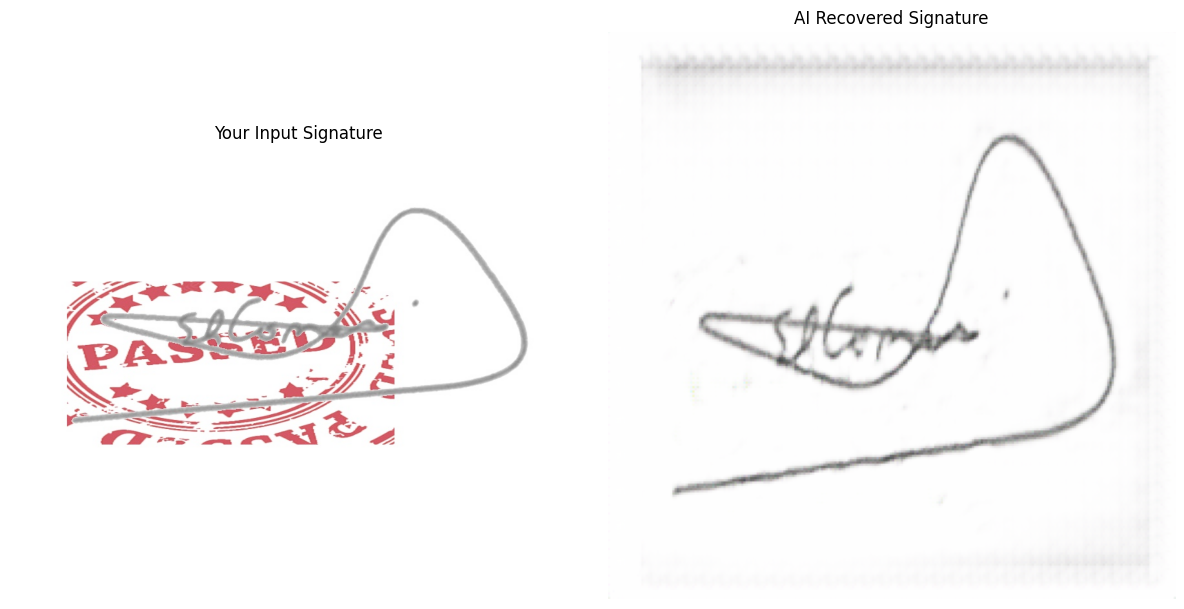

In [24]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. Setup Device and Model
device = torch.device("cuda")
model = UnetGenerator().to(device)
model.load_state_dict(torch.load("signature_recovery_h100.pth"))
model.eval()

def recover_new_signature(path_to_image):
    # Standard Pix2Pix transformation
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load your custom image - Check if path exists
    if not os.path.exists(path_to_image):
        print(f"Error: The file '{path_to_image}' was not found.")
        return

    img = Image.open(path_to_image).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(input_tensor)

    # Post-process for display
    output = output.cpu().squeeze(0).permute(1, 2, 0)
    output = (output + 1) / 2  # Map back from [-1, 1] to [0, 1]
    output = output.numpy()
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Your Input Signature")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("AI Recovered Signature")
    plt.imshow(output)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show() # This triggers the display in Jupyter

recover_new_signature('c-144-10.jpg')